0. Introduction

 In this analysis I will explore the impact of the 1973 oil crisis, and its aftermath by analyzing the most significant factors influencing the fuel efficiency of the car, based on the MPG (Miles Per Gallon) dataset provided by Seaborn library. The dataset contains data from years 1970 to 1982 regarding 398 models produced in three different parts of the world: USA, Europe and Japan. Based on that I will determine which geographical region was most affected, and why.

1. Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

2. Loading dataset and analyzing its features

In [ ]:
df = pd.read_csv("mpg_file.csv")

In [3]:
df.head()

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [4]:
df.describe()

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,198.500000,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,115.036951,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,0.000000,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,99.250000,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,198.500000,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,297.750000,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,397.000000,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    398 non-null    int64  
 1   mpg           398 non-null    float64
 2   cylinders     398 non-null    int64  
 3   displacement  398 non-null    float64
 4   horsepower    392 non-null    float64
 5   weight        398 non-null    int64  
 6   acceleration  398 non-null    float64
 7   model_year    398 non-null    int64  
 8   origin        398 non-null    object 
 9   name          398 non-null    object 
dtypes: float64(4), int64(4), object(2)
memory usage: 31.2+ KB


3. Cleaning data

In [6]:
#Creating a display of number of null values in each column.
df_nulls = df.isnull().sum().to_frame(name = 'nulls').T
df_nulls

,Unnamed: 0,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
nulls,0,0,0,0,6,0,0,0,0,0


In [7]:
#Since null values figure only in 'horsepower' column, we can calculate the ratio of the null to the entirety of the dataset.
null_ratio = df_nulls.loc['nulls', 'horsepower']/len(df)
f'Nulls ratio: {null_ratio} = {round((null_ratio*100), 2)} %'

'Nulls ratio: 0.01507537688442211 = 1.51 %'

In [8]:
#The null values are less than 2 percent of the whole data,
# thus we can remove them without a concern about truthfulness of the outcome.
df = df.dropna().copy()

In [9]:
#Searching for the duplicates in the data set.
duplicates = df.duplicated().sum()
f'There are {duplicates} duplicates in the dataset'


'There are 0 duplicates in the dataset'

Since we got rid of null values and there was no duplicate values we can move on with the analysis.

4. Correlation analysis

In [10]:
#Now I will analyze possible factors influencing the efficiency of the car (mpg).
df_mpg_cor = df[['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']].corr()['mpg']
df_mpg_cor.sort_values(ascending=False)

mpg             1.000000
model_year      0.580541
acceleration    0.423329
cylinders      -0.777618
horsepower     -0.778427
displacement   -0.805127
weight         -0.832244
Name: mpg, dtype: float64

Above there is a correlation matrix between miles per gallon ('mpg') and the following factors: cylinders, displacement, horsepower, weight, acceleration and model year. At the top we can see that model year has positive correlation with mpg of 0.57. Based on this we can speculate that with time the efficiency of cars improved, likely due to legal regulations and technological improvement.

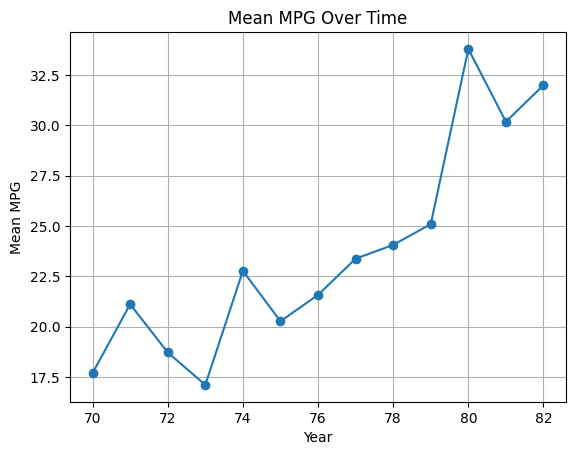

In [11]:
#Closer look at that relation. Mean mpg per year.
mean_mpg_per_year = df.groupby('model_year')['mpg'].mean()
plt.plot(mean_mpg_per_year, marker='o')
plt.xlabel('Year') 
plt.ylabel('Mean MPG')
plt.title('Mean MPG Over Time')
plt.grid()
plt.show()

Indeed, the fuel efficiency seems to  improve over time. Moreover, we can observe that after 1975 there is an upward trend of fuel efficiency. This correlates with Corporate Average Fuel Economy (CAFE) regulation introduced in USA in that very year, which were meant to make american cars more fuel efficient. This initiative was motivated by 1973 oil crisis caused by OAPEC (Organization of Arab Petroleum Exporting Countries) imposing an oil embargo on the United States and other nations supporting Israel during the Yom Kippur War.   Secoundly we can see a sudden spike of fuel efficiency after 1979. This coincides with 1979 fuel crisis triggered by the Iranian Revolution, which disrupted global oil supplies and caused widespread panic over gasoline shortages. Let’s look then more closely on mean MPG of particualr regiona, especially USA.

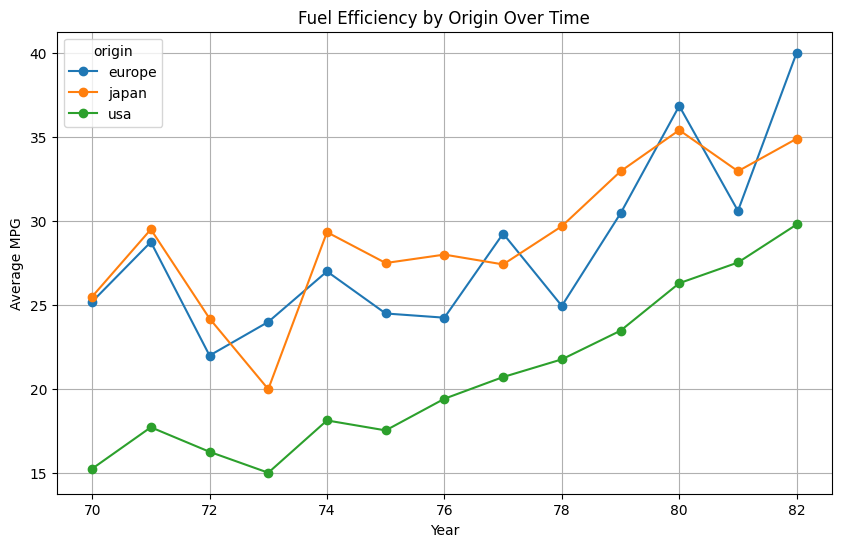

In [12]:
origin = df.groupby(['model_year', 'origin'])['mpg'].mean()
origin.unstack().plot(figsize=(10, 6), marker='o')
plt.xlabel('Year')
plt.ylabel('Average MPG')
plt.title('Fuel Efficiency by Origin Over Time')
plt.grid()
plt.show()

The above plot gives us some clarity. USA mpg has steady growth since 1975. We can also see the 1973 oil crisis for US and Japan. It also clear that US, despite its improvements since 1975 remained least fuel efficient compared to Europe and Japan. Additionally, Europe's mpg seemed rather unaffected by '73 oil crisis. To investigate further let's pay a closer look at highest negative correlation on the list: weight and mpg.

In [13]:
df_weight_cor = df[['weight', 'mpg', 'cylinders', 'displacement', 'horsepower', 'acceleration', 'model_year']].corr()['weight']
df_weight_cor.sort_values()

mpg            -0.832244
acceleration   -0.416839
model_year     -0.309120
horsepower      0.864538
cylinders       0.897527
displacement    0.932994
weight          1.000000
Name: weight, dtype: float64

Weight, as we can see, has strong negative correlation with mpg of -0.83. Heavier cars require more energy to move. Based on previous investigation we can posit that US produces overall heavier cars compared to Japan and Europe. Let's think of a classic Cadillac, which depending on the model could weight from approximately 4,600 lbs (2,087 kg) to over 5,500 lbs (2,495 kg), as an example. Additionally we can expect that after 1973 the average weight of the car produced in USA was declining. In order to test that, we can create a similar plot as previously, but with Average Weight instead of Average MPG over time.

5. Analysis of the average weight of the car in the USA, Europe and Japan

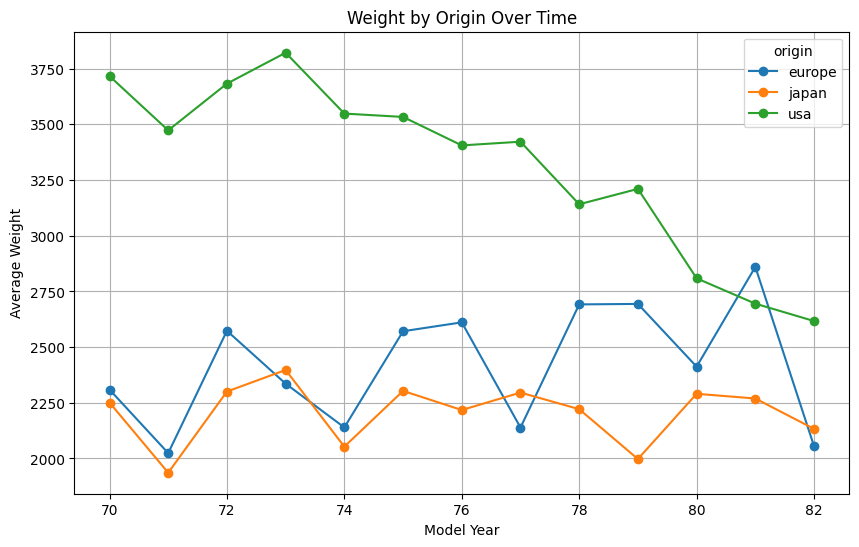

In [14]:
weight = df.groupby(['model_year', 'origin'])['weight'].mean()
weight.unstack().plot(figsize=(10, 6), marker = 'o')
plt.xlabel('Model Year')
plt.ylabel('Average Weight')
plt.title('Weight by Origin Over Time')
plt.grid()
plt.show()

In the above chart we can see that indeed USA had the heaviest cars, with the exception of the year 1981 where it was temporarily surpassed by Europe. The fact that Europe was not dramatically influenced by 1973 oil crisis is likely due to the fact that the average weight of the vehicles was on steady decline since 1972 and in 1973 was around 2300, so there was little room for immediate improvement, comparing to the average weight of a car in the USA in the same year which was over 3750. Additionally, due to very high correlation between weight, displacement and number of cylinders we can posit that this was the area which american manufacturers were concerned the most.

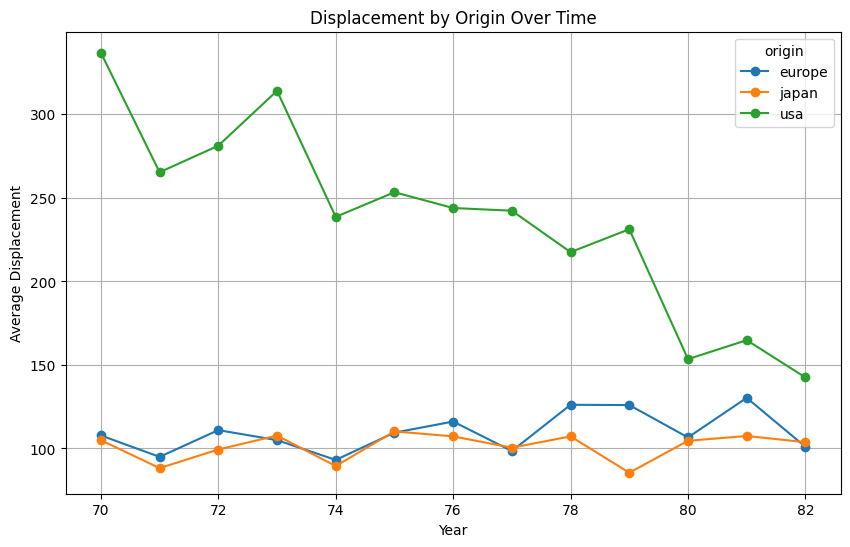

In [15]:
origin = df.groupby(['model_year', 'origin'])['displacement'].mean()
origin.unstack().plot(figsize=(10, 6), marker='o')
plt.xlabel('Year')
plt.ylabel('Average Displacement')
plt.title('Displacement by Origin Over Time')
plt.grid()
plt.show()

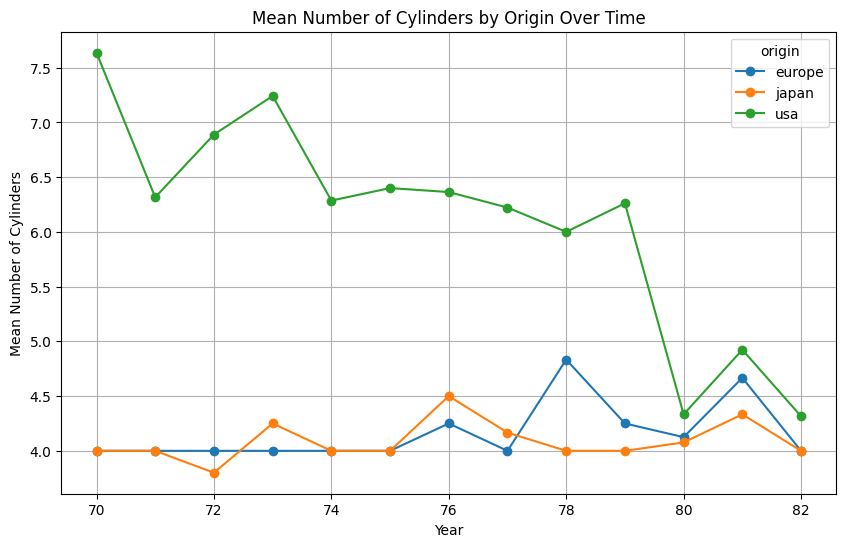

In [16]:
origin = df.groupby(['model_year', 'origin'])[ 'cylinders'].mean()
origin.unstack().plot(figsize=(10, 6), marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Number of Cylinders')
plt.title('Mean Number of Cylinders by Origin Over Time')
plt.grid()
plt.show()

As expected, displacement chart and cyliners chart looks very similar to that of weight, especially for US. 

6. Which region was most affected?

In [17]:
before_crisis = df[df['model_year'] <= 73].groupby('origin')['mpg'].mean()
after_crisis = df[(df['model_year'] >= 74) & (df['model_year'] <= 80)].groupby('origin')['mpg'].mean()
mpg_improvement = ((after_crisis - before_crisis)/before_crisis*100)
mean_mpg = pd.DataFrame({'Mean MPG Before crisis (1970-73)': before_crisis.round(1), 'Mean MPG After crisis (1974-80)': after_crisis.round(1)})
improvements = pd.DataFrame({'Mean MPG improvements (%)': mpg_improvement.round(1)})
improvements

,Mean MPG improvements (%)
origin,
europe,14.3
japan,25.0
usa,29.7


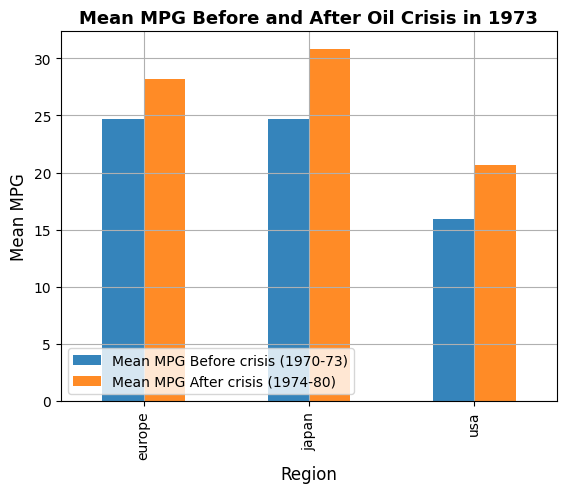

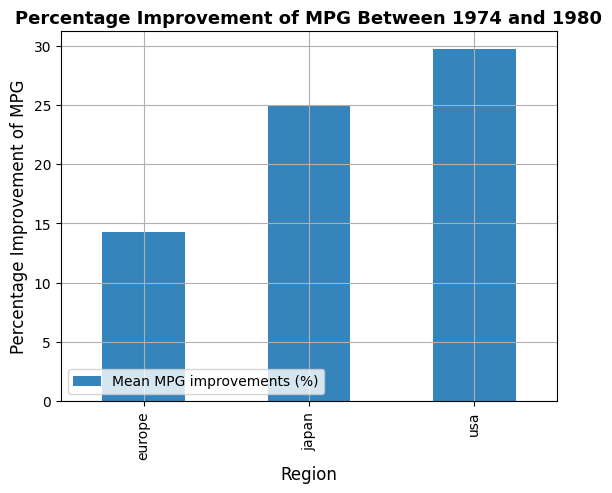

In [18]:
ax1 = mean_mpg.plot(kind='bar', alpha=0.9)
plt.title('Mean MPG Before and After Oil Crisis in 1973', fontweight ='bold', fontsize=13)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Mean MPG', fontsize=12)
plt.grid()
plt.legend(loc='lower left')

improvements.plot(kind='bar', alpha=0.9)
plt.title('Percentage Improvement of MPG Between 1974 and 1980',fontweight ='bold', fontsize=13)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage Improvement of MPG', fontsize=12)
plt.grid()
plt.legend(loc='lower left')

The most affected region turns out to be USA, improving their fuel efficiency by 29.7%. This means that America reacted to the 1973 oil crisis by making the most drastic changes in their car manufacture. In the close second place is Japan with 25.0% and Europe with only 14.3%. Why is that?

USA had the heaviest cars, therefore the biggest possibility to improve their fuel efficiency by decreasing the weight of their vehicles. If we take a closer look at 'Weight by Origin Over Time' chart we can see steady decline in mean weight of cars from the USA. Impressive improvements in Japan could be attributed to technological innovations paired with consistently light weight of their vehicles. Europes manufacturers were less concerned with keeping their cars super-lightweight as they are mostly heavier than Japanese ones, while still being much lighter than cars from USA.

7. Possible limitations of the dataset

In [19]:
df.groupby('origin')['name'].nunique()

origin
europe     56
japan      60
usa       185
Name: name, dtype: int64

Despite our findings it has to be pointed out that based on our dataset USA is leading not only heavy cars but also in the amount of models produced. This might be interpreted in two ways:
1. USA indeed produced significantly more car models than other regions.
2. There is a sampling bias that stems from the fact that more data was acquired from USA than other regions.

Unfortunately it is impossible to determine which scenario is correct based solely on the dataset.

8. Conclusion

Despite the possible limitations of the dataset the key findings of the analysis remain valid. The weight of the vehicle is the strongest indicator of mpg, having a negative correlation of -0.83. This correlation alone can help us understand a lot of what was happening in car manufacture in the 70's and 80's.

America, having the heaviest cars out of the three regions, had the biggest area for improvement. After the oil crisis in 1973 which brought about CAFE regulations in 1975, USA began steadily decreasing the weight of their vehicles in order to increase the MPG. Indeed, USA made the most drastic improvements in fuel efficiency of their cars increasing it by 29.7%.

Additionally, Japan also made significant upscales to their car efficiency (from 24.7 to 30.8 miles per gallon), making Europe the least affected region. However, this does not mean that USA became the most fuel efficient, quite the opposite. Even though mean mpg of American cars after the crisis improved the most (from 15.9 to 20.7 miles per gallon) USA still remained far behind the other two regions: Japan at 30.8 and Europe at 28.2.

Japan having best results in fuel efficiency might be coming from the technological innovations and consistently lightweight cars. Europe, on the other hand, was slightly less efficient by having heavier cars than Japan. The smaller improvement in those two regions was most likely due to already being more optimized than the US manufacture.